In [3]:
# pip install wordcloud

In [4]:
from elasticsearch import Elasticsearch
import pandas as pd
import json
from ipywidgets import interact, Dropdown
import matplotlib.pyplot as plt
import warnings
import urllib3
import time
import requests
import numpy as np
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
import ipywidgets as widgets

# Suppress all warnings
warnings.filterwarnings("ignore")

# Suppress only InsecureRequestWarning from urllib3 (for verify_certs=False)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# === API Parameter ===
api_url = "http://localhost:9090/api/youtubeelectionapi"

# === Define two ranges to avoid 10,000 limit ===
ranges = [
    {"start": "2024-03-01", "end": "2025-03-20"},
    {"start": "2025-03-21", "end": "2026-01-01"}
]

# === Fetch & Combine ===
all_data = []

for i, params in enumerate(ranges):
    response = requests.get(api_url, params=params)
    if response.status_code == 200:
        json_data = response.json()
        results = json_data.get("data", [])
        print(f"[OK] Retrieved {len(results)} documents from range {i+1}")
        all_data.append(pd.DataFrame(results))
    else:
        print(f"[X] Request {i+1} failed with status code {response.status_code}")

# === Combine & Clean ===
if all_data:
    yte_df_raw = pd.concat(all_data, ignore_index=True)
    print(f"[✓] Combined total: {len(yte_df_raw)} rows.")
    display(yte_df_raw.columns)
else:
    print("[X] No data retrieved from any range.")

[OK] Retrieved 3532 documents from range 1
[OK] Retrieved 9557 documents from range 2
[✓] Combined total: 13089 rows.


Index(['snippet', 'search_prompt', 'kind', 'etag', 'id', 'contentDetails',
       'statistics'],
      dtype='object')

In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import time

# Normalize raw data
yte_df = pd.json_normalize(yte_df_raw.to_dict(orient='records'))

# Ensure numeric types for relevant fields
for field in ['statistics.viewCount', 'statistics.likeCount', 'statistics.commentCount', 'statistics.favoriteCount']:
    yte_df[field] = yte_df[field].astype(float)

# Parse and localize datetime
yte_df['snippet.publishedAt'] = pd.to_datetime(yte_df['snippet.publishedAt'], utc=True)
yte_df['published_melbourne'] = yte_df['snippet.publishedAt'].dt.tz_convert('Australia/Melbourne')

# Calculate hours since posted using datetime difference
now = pd.Timestamp.now(tz='UTC')
yte_df['hours_since_post'] = (now - yte_df['snippet.publishedAt']).dt.total_seconds() / 3600

# Compute raw weighted score
yte_df['raw_score'] = (
    yte_df['statistics.viewCount'] * 0.5 +
    yte_df['statistics.likeCount'] * 1.0 +
    yte_df['statistics.commentCount'] * 1.5 +
    yte_df['statistics.favoriteCount'] * 1.2
)

# Exponential decay (freshness factor)
yte_df['decay'] = np.exp(-0.05 * yte_df['hours_since_post'] / 24)

# Hotness score = raw * decay
yte_df['score1'] = yte_df['raw_score'] * yte_df['decay']

# Engagement score per view
yte_df['statistics.viewCount'] = yte_df['statistics.viewCount'].replace(0, 1)  # Avoid div-by-zero
yte_df['score2'] = (
    (yte_df['statistics.likeCount'] / yte_df['statistics.viewCount']) +
    2 * (yte_df['statistics.commentCount'] / yte_df['statistics.viewCount']) +
    3 * (yte_df['statistics.favoriteCount'] / yte_df['statistics.viewCount'])
) * 100

# Clean up invalid values
yte_df[['score1', 'score2']] = yte_df[['score1', 'score2']].replace([np.inf, -np.inf], np.nan).fillna(0)



# Scale to [1, 100]
def clip_and_scale(series, feature_range=(1, 100)):
    lower = series.quantile(0.05)
    upper = series.quantile(0.95)
    clipped = series.clip(lower, upper)
    scaler = MinMaxScaler(feature_range=feature_range)
    return scaler.fit_transform(clipped.values.reshape(-1, 1))

def log_clip_scale(series, feature_range=(1, 100)):
    log_vals = np.log1p(series)  # log(1 + x) 防止 log(0)
    lower = log_vals.quantile(0.05)
    upper = log_vals.quantile(0.95)
    clipped = log_vals.clip(lower, upper)
    scaler = MinMaxScaler(feature_range=feature_range)
    return scaler.fit_transform(clipped.values.reshape(-1, 1))

yte_df['score1_scaled'] = log_clip_scale(yte_df['score1'])
# score1_log = np.log1p(yte_df['score1'])
# yte_df['score1_scaled'] = scaler.fit_transform(score1_log.values.reshape(-1, 1))
yte_df['score2_scaled'] = clip_and_scale(yte_df['score2'])

# Optional: print info
print("[OK] DataFrame processed. Available columns:")
# print(yte_df.columns.tolist())
# yte_df.head()


[OK] DataFrame processed. Available columns:


In [6]:
import ipywidgets as widgets

# Get min and max dates in local (Melbourne) time
start_date_actual = yte_df['published_melbourne'].min().date()
end_date_actual = yte_df['published_melbourne'].max().date()

# Generate full date range list for slider
date_range = pd.date_range(start=start_date_actual, end=end_date_actual, freq='D')
date_slider = widgets.SelectionRangeSlider(
    options=[d.strftime("%Y-%m-%d") for d in date_range],
    index=(0, len(date_range) - 1),
    description='Date Range:',
    orientation='horizontal',
    layout={'width': '100%'}
)

# Frequency resolution dropdown
resolution = widgets.Dropdown(
    options=[('Hourly', 'H'), ('Every 3 Hours', '3H'), ('Daily', 'D'), ('Weekly', 'W')],
    value='H',
    description='Resolution:'
)

# Combine controls into a UI layout
ui = widgets.VBox([date_slider, resolution])

# Plotting function triggered by widget updates
def update_all_plots(date_range, freq):
    start_str, end_str = date_range
    # Localize start and end to Melbourne timezone to match the DataFrame
    start = pd.to_datetime(start_str).tz_localize("Australia/Melbourne")
    end = pd.to_datetime(end_str).tz_localize("Australia/Melbourne")


    # Filter DataFrame based on selected date range
    yte_df_filtered = yte_df[(yte_df['published_melbourne'] >= start) & (yte_df['published_melbourne'] <= end)]

    if yte_df_filtered.empty:
        print("No data for selected range.")
        return

    # Set time column as index for resampling
    yte_df_tmp = yte_df_filtered.set_index('published_melbourne')

    # Resample metrics
    resampled_count = yte_df_tmp.resample(freq).size()
    resampled_views = yte_df_tmp['statistics.viewCount'].resample(freq).sum()
    resampled_score1 = yte_df_tmp['score1'].resample(freq).mean()
    resampled_score2 = yte_df_tmp['score2'].resample(freq).mean()

    # Create subplots
    fig, axs = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

    axs[0].plot(resampled_count.index, resampled_count.values, marker='o')
    axs[0].set_title(f'Number of Uploaded Videos ({freq} resolution)')
    axs[0].set_ylabel("Upload Count")
    axs[0].grid(True)

    axs[1].plot(resampled_views.index, resampled_views.values, marker='o', color='green')
    axs[1].set_title(f'Total View Count ({freq} resolution)')
    axs[1].set_ylabel("Total Views")
    axs[1].grid(True)

    axs[2].plot(resampled_score1.index, resampled_score1.values, marker='o', color='red')
    axs[2].set_title(f'Average Score1 Over Time ({freq} resolution)')
    axs[2].set_ylabel("Average Score1")
    axs[2].grid(True)

    axs[3].plot(resampled_score2.index, resampled_score2.values, marker='o', color='orange')
    axs[3].set_title(f'Average Score2 Over Time ({freq} resolution)')
    axs[3].set_ylabel("Average Score2")
    axs[3].grid(True)

    for ax in axs:
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Connect the UI widgets to the plotting function
out_all = widgets.interactive_output(update_all_plots, {
    'date_range': date_slider,
    'freq': resolution
})

# Display the full UI and output
display(ui, out_all)


Output()

In [7]:
def update_all_plots(date_range, freq):
    # Convert strings to tz-aware datetimes
    start_str, end_str = date_range
    start = pd.to_datetime(start_str).tz_localize("Australia/Melbourne")
    end = pd.to_datetime(end_str).tz_localize("Australia/Melbourne")


    # Filter using datetime column (not index)
    yte_df_filtered = yte_df[(yte_df['published_melbourne'] >= start) & (yte_df['published_melbourne'] <= end)]

    if yte_df.empty:
        print("No data for selected range.")
        return

    # Resample by column instead of index
    resampled_count = yte_df_filtered.resample(freq, on='published_melbourne').size()
    resampled_views = yte_df_filtered.resample(freq, on='published_melbourne')['statistics.viewCount'].sum()
    resampled_score1 = yte_df_filtered.resample(freq, on='published_melbourne')['score1'].mean()
    resampled_score2 = yte_df_filtered.resample(freq, on='published_melbourne')['score2'].mean()

    # Plotting
    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Subplot 1: Upload Count vs View Count
    ax1 = axs[0]
    ax2 = ax1.twinx()
    ax1.plot(resampled_count.index, resampled_count.values, label='Upload Count', color='blue', marker='o')
    ax2.plot(resampled_views.index, resampled_views.values, label='View Count', color='green', marker='x')
    ax1.set_ylabel("Upload Count", color='blue')
    ax2.set_ylabel("Total Views", color='green')
    ax1.set_title(f'Uploads and Views Over Time ({freq} resolution)')
    ax1.grid(True)

    # Subplot 2: Score1 vs Score2
    ax3 = axs[1]
    ax4 = ax3.twinx()
    ax3.plot(resampled_score1.index, resampled_score1.values, label='Score1', color='red', marker='o')
    ax4.plot(resampled_score2.index, resampled_score2.values, label='Score2', color='orange', marker='x')
    ax3.set_ylabel("Avg Score1", color='red')
    ax4.set_ylabel("Avg Score2", color='orange')
    ax3.set_title(f'Score1 and Score2 Over Time ({freq} resolution)')
    ax3.grid(True)

    # Combine legends for Subplot 1
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axs[0].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    # Combine legends for Subplot 2
    lines3, labels3 = ax3.get_legend_handles_labels()
    lines4, labels4 = ax4.get_legend_handles_labels()
    axs[1].legend(lines3 + lines4, labels3 + labels4, loc='upper left')

    for ax in axs:
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(update_all_plots, {
    'date_range': date_slider,
    'freq': resolution
})
display(ui, out)

Output()

In [8]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

def extract_text(row):
    text = row.get('snippet.title', '') + " " + row.get('snippet.description', '')
    tags = row.get('snippet.tags', [])
    if isinstance(tags, list):
        text += " " + " ".join(tags)
    return text

yte_df['text'] = yte_df.apply(extract_text, axis=1)

from wordcloud import STOPWORDS
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)      # Remove links
    text = re.sub(r'[^\w\s]', '', text)      # Remove punctuation
    return text

yte_df['clean_text'] = yte_df['text'].fillna('').apply(clean_text)



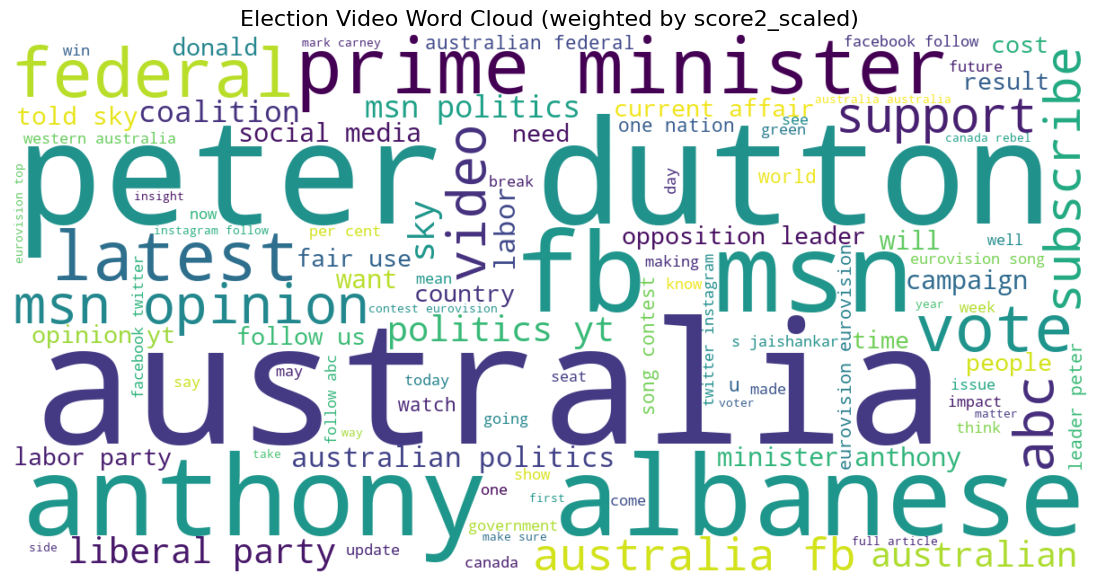

In [9]:
def weighted_text(row, weight_col='score2_scaled'):
    weight = int(row[weight_col] // 10) 
    return (row['clean_text'] + ' ') * max(1, weight)

yte_df['weighted_text'] = yte_df.apply(weighted_text, axis=1)
combined_text = ' '.join(yte_df['weighted_text'])
from wordcloud import WordCloud
import matplotlib.pyplot as plt

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'live', 'youtube', 'new', 'shorts', 'channel', 
    'election', 'news', 'breaking', 'trump'           
])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=100
).generate(combined_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Election Video Word Cloud (weighted by score2_scaled)", fontsize=16)
plt.show()


In [10]:
def plot_wordcloud_ax(df, title, ax, weight_col='score2_scaled'):
    def weighted_text(row):
        weight = int(row[weight_col] // 10)
        return (row['clean_text'] + ' ') * max(1, weight)

    df = df.copy()
    df['weighted_text'] = df.apply(weighted_text, axis=1)
    combined_text = ' '.join(df['weighted_text'])

    custom_stopwords = set(STOPWORDS)
    custom_stopwords.update([
        'live', 'youtube', 'new', 'shorts', 'channel', 'u',
        'election', 'news', 'breaking', 'trump', 'donald', 'match', 
        'australia', 'latest', 'follow', 'subscribe', 'son'
    ])

    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        stopwords=custom_stopwords,
        max_words=10
    ).generate(combined_text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14)


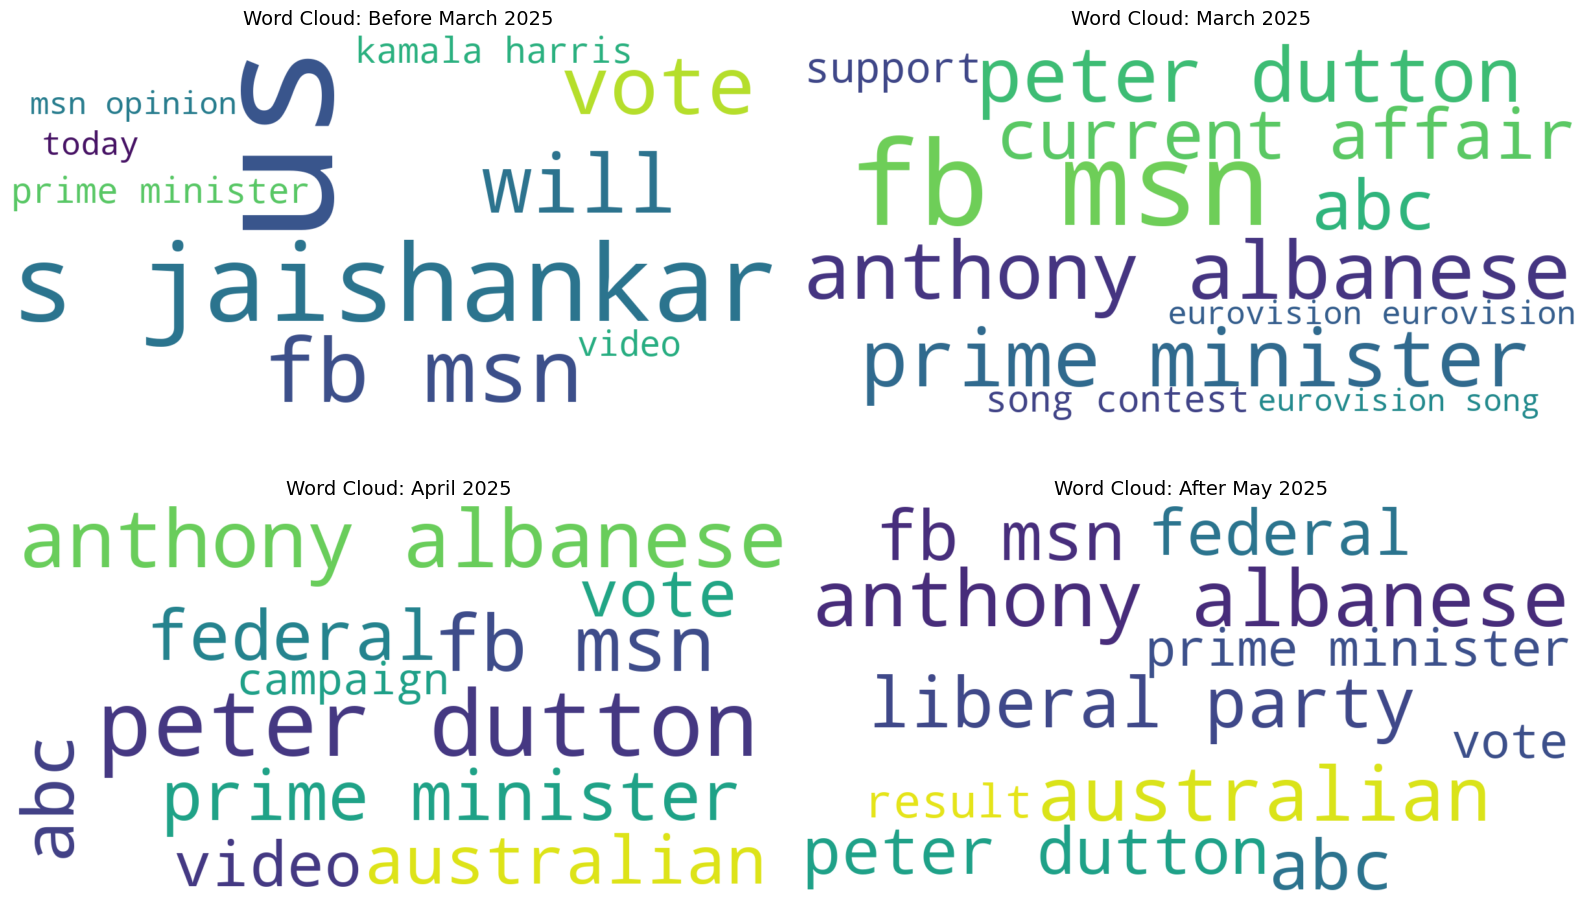

In [12]:
# Define time boundaries
march_cutoff = pd.Timestamp("2025-03-01", tz="Australia/Melbourne")
april_start = pd.Timestamp("2025-04-01", tz="Australia/Melbourne")
may_start = pd.Timestamp("2025-05-01", tz="Australia/Melbourne")

# Slice data by time range
before_march = yte_df[yte_df['published_melbourne'] < march_cutoff]
march_only = yte_df[(yte_df['published_melbourne'] >= march_cutoff) & (yte_df['published_melbourne'] < april_start)]
april_only = yte_df[(yte_df['published_melbourne'] >= april_start) & (yte_df['published_melbourne'] < may_start)]
after_may = yte_df[yte_df['published_melbourne'] >= may_start]

# Prepare 2×2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()

time_slices = [
    (before_march, "Before March 2025"),
    (march_only, "March 2025"),
    (april_only, "April 2025"),
    (after_may, "After May 2025"),
]

for ax, (df_part, title) in zip(axs, time_slices):
    plot_wordcloud_ax(df_part, f"Word Cloud: {title}", ax)

plt.tight_layout()
plt.show()


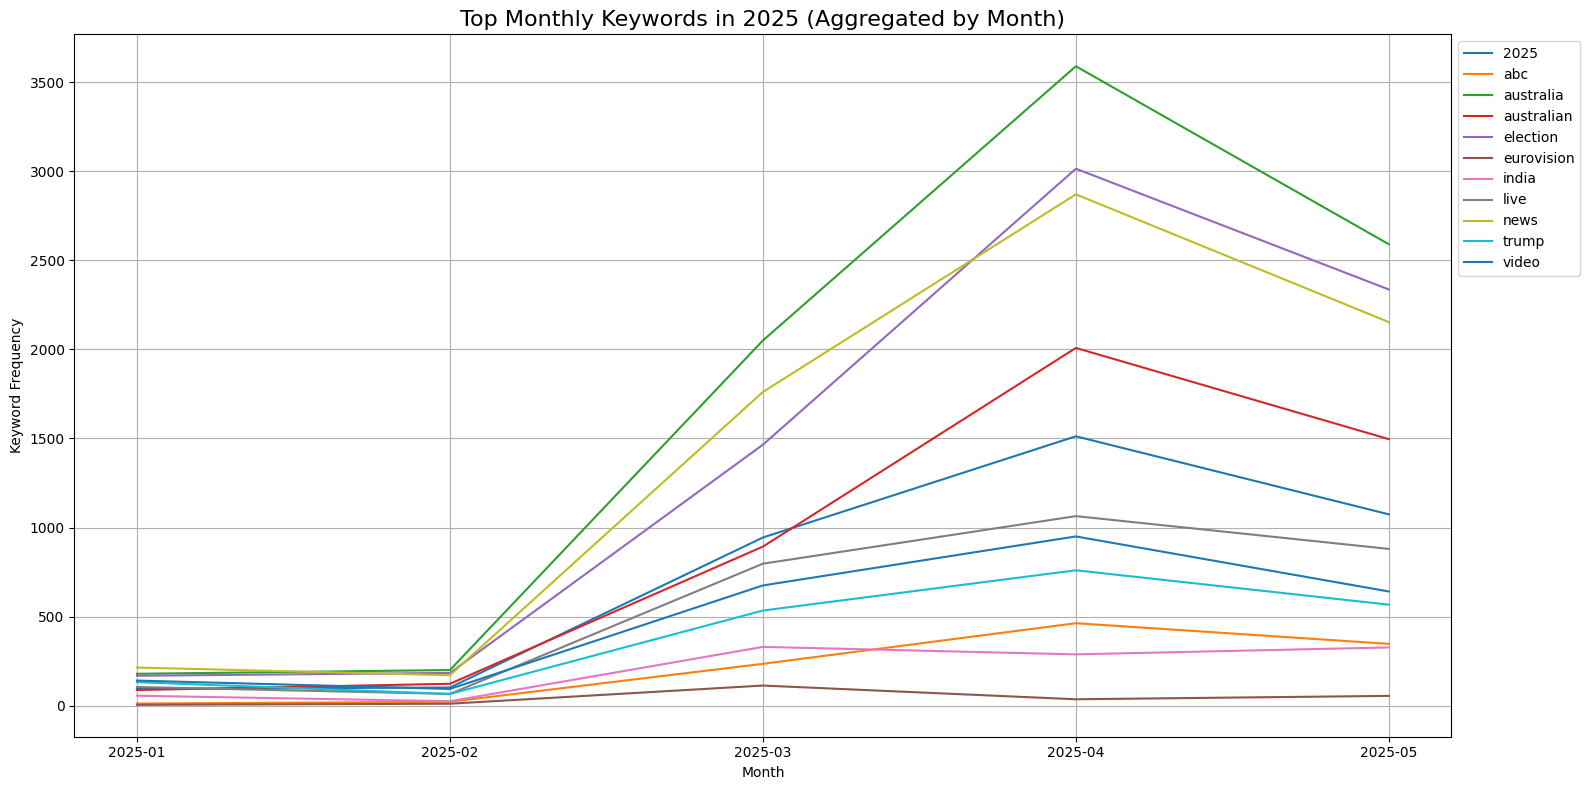

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

# Filter data for year 2025 only
yte_df['published_melbourne'] = pd.to_datetime(yte_df['published_melbourne'])
yte_df = yte_df[yte_df['published_melbourne'].dt.year == 2025]

# Extract month column
yte_df['month'] = yte_df['published_melbourne'].dt.to_period('M')

# Define stopwords
stopwords_set = set(STOPWORDS)

# Step 1: Extract top 10 keywords per month
monthly_keywords = {}
for month, group in yte_df.groupby('month'):
    words = ' '.join(group['clean_text']).split()
    filtered_words = [w for w in words if w not in stopwords_set and len(w) > 2]
    counter = Counter(filtered_words)
    monthly_keywords[month] = [w for w, _ in counter.most_common(6)]

# Step 2: Get union of all top keywords
top_keywords_all = sorted(set(word for words in monthly_keywords.values() for word in words))

# Step 3: Create keyword presence columns
for kw in top_keywords_all:
    yte_df[kw] = yte_df['clean_text'].apply(lambda x: int(kw in x))

# Step 4: Aggregate by month
monthly_trend = yte_df.groupby('month')[top_keywords_all].sum().reset_index()

# Step 5: Plot
plt.figure(figsize=(16, 8))
for kw in top_keywords_all:
    plt.plot(monthly_trend['month'].astype(str), monthly_trend[kw], label=kw)

plt.title("Top Monthly Keywords in 2025 (Aggregated by Month)", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Keyword Frequency")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()
